# Analyse Base Graph

# Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import os
import pandas as pd
from pathlib import Path
import pickle
import seaborn as sns
from scipy import stats
from tqdm import tqdm as tqdm

# Directories

In [4]:
# Define current directory
cwd = Path.cwd()
# Define DATA directory
DATA = cwd.parents[1]/'data'/'canada'

# Define INPUT directory
INPUT = DATA / 'input'

# Define DAVID directory
DAVID = INPUT / 'david'

# Define OUTPUT directory
OUTPUT = DATA / 'output'

# Functions

## General

In [5]:
def file_to_list(path):
    '''
    Converts a .txt file to a list
    '''

    with open(f'{path}', 'r', encoding = 'utf-8') as f:
        list_file = [line.strip() for line in f]
    
    return list_file

def list_to_file(path, data):
      '''
      Saves a list or set to a .txt file with no header.
      '''

      with open(path, 'w') as f:
            for item in sorted(data):
                  f.write(f'{item}\n')

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()

# Graph

## Visualise Network(s)

Generate plot of full network w/ landmark network overlayed.

In [6]:
# Load base graph
graph_base = pickle_load(OUTPUT / 'graph_base.pkl')
# Load landmark graph
graph_landmark = pickle_load(OUTPUT / 'graph_landmark.pkl')

# Get largest connected component
list_cc = list(max(nx.connected_components(graph_base), key = len))
# Generate subgraph
subgraph_base = nx.subgraph(graph_base, list_cc)

# Calculate positional data for graph_base
pos = nx.spring_layout(subgraph_base, k = 0.75)

# Save positional data
pickle_save(OUTPUT / 'graph_base_pos.pkl', pos)

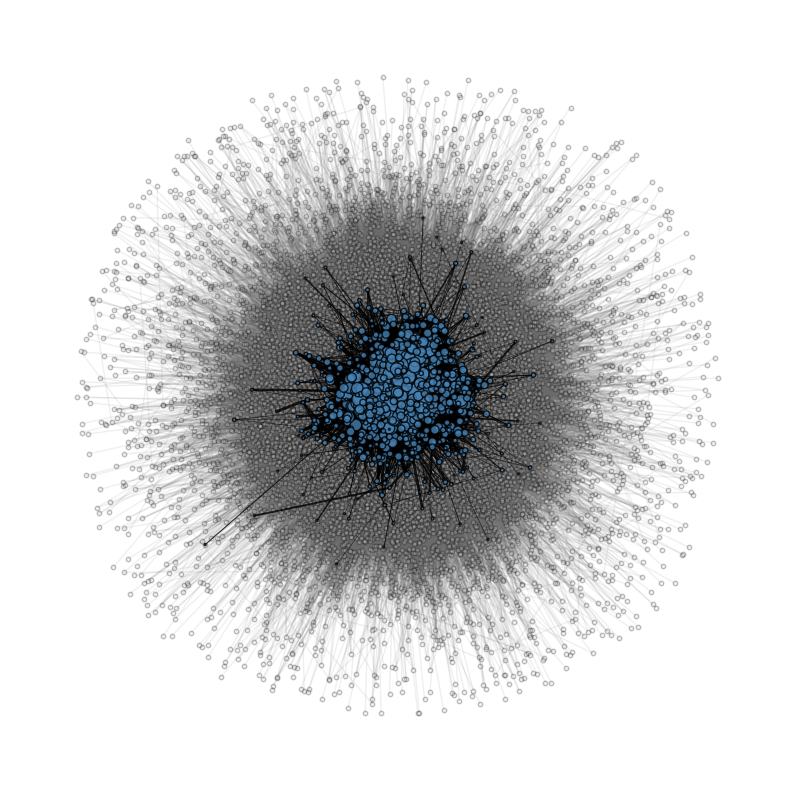

In [7]:
# Load positional data
pos = pickle_load(OUTPUT / 'graph_base_pos.pkl')

# Plot
plt.figure(figsize = (10,10))
# Draw base edges
full_edges = nx.draw_networkx_edges(subgraph_base, pos = pos, edge_color = 'dimgrey', alpha = 0.1)
full_edges.set_zorder(1)
# Draw base nodes
full_nodes = nx.draw_networkx_nodes(subgraph_base, pos = pos, node_size = 10, node_color = 'lightgrey', edgecolors = 'black', alpha = 0.25)
full_nodes.set_zorder(2)

# Calculate degrees
list_degrees = [nx.degree(graph_landmark, nbunch = node) for node in graph_landmark.nodes]
list_degrees = [entry * 2 for entry in list_degrees]
# Calculate weights
list_weights = [weight for source, target, weight in graph_landmark.edges(data = 'weight')]
list_weights = [entry / 500 for entry in list_weights]

# Draw landmark edges
lm_edges = nx.draw_networkx_edges(graph_landmark, pos = pos, edge_color = 'black', alpha = 0.8, width = list_weights)
lm_edges.set_zorder(3)
# Draw landmark nodes
lm_nodes = nx.draw_networkx_nodes(graph_landmark, pos = pos, node_size = list_degrees, node_color = 'steelblue', edgecolors = 'black', alpha = 0.8)
lm_nodes.set_zorder(4)

plt.axis('off');

## Histogram of edge weights

Generate a histogram w/ edge weights for full and landmark graph

Text(0.5, 0, 'STRING Edge Weight')

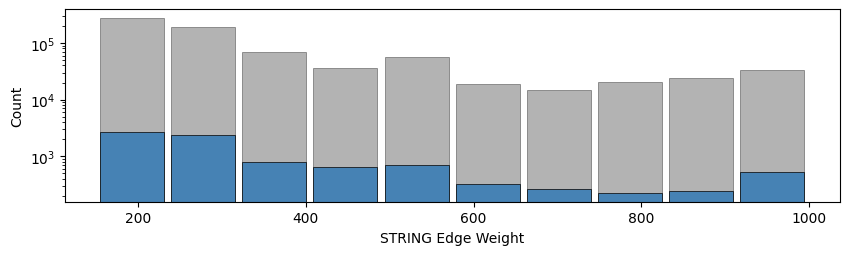

In [8]:
# Edge weights for full graph
list_weights_full = [weight for source, target, weight in subgraph_base.edges(data = 'weight')]
# Edge weights for landmark graph
list_weights_landmark = [weight for source, target, weight in graph_landmark.edges(data = 'weight')]

# Plot
plt.figure(figsize = (10, 2.5))
plt.hist(list_weights_full, rwidth = 0.9, color = 'dimgrey', edgecolor = 'black', linewidth = 0.5, alpha = 0.5)
plt.hist(list_weights_landmark, rwidth = 0.9, color = 'steelblue', edgecolor = 'black', linewidth = 0.5)
plt.yscale('log')
plt.ylabel('Count')
plt.xlabel('STRING Edge Weight')

## Landmark Connectivity

Compares connectivity of landmark genes vs all other genes in base graph.

In [9]:
# Load base graph
graph_base = pickle_load(OUTPUT / 'graph_base.pkl')
# Load landmark graph
graph_landmark = pickle_load(OUTPUT / 'graph_landmark.pkl')

# Get landmark nodes
list_landmark = list(graph_landmark.nodes)

# Initialise degree data
list_degree = []

for node in graph_base.nodes:
    degree = graph_base.degree(node)
    label = 'landmark' if node in list_landmark else 'non_landmark'
    list_degree.append((degree, label))

# Generate dataframe
df_degree = pd.DataFrame(columns = ['degree', 'lm'], data = list_degree)
# Calculate neighbours as percent of all nodes
df_degree['percent'] = df_degree['degree'] / len(graph_base.nodes) * 100

# # Get degree of landmark nodes in subgraph
# list_subgraph_degree = [graph_landmark.degree(node) for node in graph_landmark.nodes]
# # Generate dataframe
# df_subgraph = pd.DataFrame(columns = ['degree'], data = list_subgraph_degree)
# df_subgraph['lm'] = 'landmark_subgraph'
# df_subgraph['percent'] = df_subgraph['degree'] / len(graph_landmark.nodes) * 100
# # Concatenate
# df_degree = pd.concat([df_degree, df_subgraph])

# Show data
df_degree.head()

,degree,lm,percent
0,123,non_landmark,0.655406
1,100,non_landmark,0.532850
2,45,landmark,0.239783
3,63,non_landmark,0.335696
4,139,non_landmark,0.740662


C:\Users\roman\AppData\Local\Temp\ipykernel_21936\2093644997.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(df_degree, x = 'degree', y = 'lm', orient = 'h',


Text(0, 0.5, '')

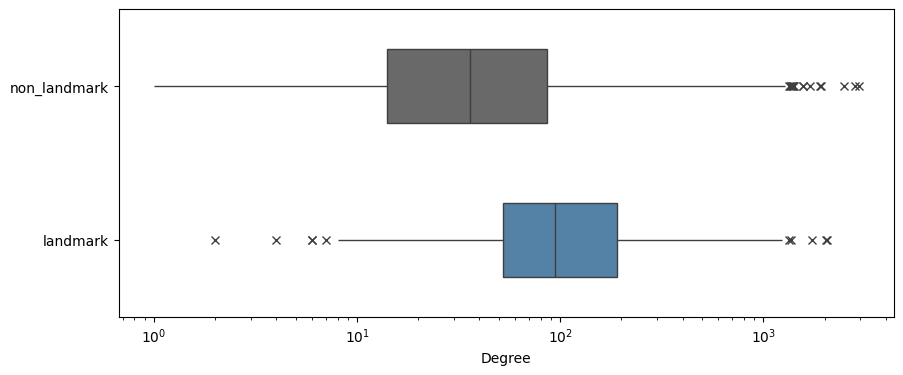

In [10]:
# Plot
plt.figure(figsize = (10,4))
sns.boxplot(df_degree, x = 'degree', y = 'lm', orient = 'h',
            hue = 'lm', palette = ['dimgrey', 'steelblue', 'indianred'],
            log_scale = True, 
            gap = 0.4,
            showcaps = False,
            flierprops = {'marker' : 'x'})
plt.xlabel('Degree')
plt.ylabel('')

# # Plot
# plt.figure(figsize = (10,4))
# sns.boxplot(df_degree, x = 'percent', y = 'lm', orient = 'h',
#             hue = 'lm', palette = ['dimgrey', 'steelblue', 'indianred'],
#             log_scale = True, 
#             gap = 0.4,
#             showcaps = False,
#             flierprops = {'marker' : 'x'})
# plt.xlabel('% Connectivity (Degree / Total Nodes)')
# plt.ylabel('')

## Landmark GO Terms

For each GO Category (BP, CC, MF), get the number of unique node IDs listed, and calculate what % of nodes associate with each Term within the Category. 

This is compared this between landmark and non_landmark nodes, to see if landmark nodes give relatively similar functional representation for later interpretation.

In [11]:
# Load base graph
graph_base = pickle_load(OUTPUT / 'graph_base.pkl')
# Load landmark graph
graph_landmark = pickle_load(OUTPUT / 'graph_landmark.pkl')

# Get landmark nodes
list_landmark = list(graph_landmark.nodes)
# Get non landmark nodes
list_nonlandmark = [node for node in graph_base.nodes if node not in list_landmark]

# Export node lists
list_to_file(OUTPUT / 'go_list_landmark.txt', list_landmark)
list_to_file(OUTPUT / 'go_list_nonlandmark.txt', list_nonlandmark)

In [12]:
# Load data
df_landmark = pd.read_csv(DAVID / 'david_list_landmark.csv')
df_nonlandmark = pd.read_csv(DAVID / 'david_list_nonlandmark.csv')

# Define category map
category_map = {
    'GOTERM_BP_DIRECT' : 'GO Biological Process',
    'GOTERM_CC_DIRECT' : 'GO Cellular Compartment',
    'GOTERM_MF_DIRECT' : 'GO Molecular Function'
}

# Initialise dataframe
df_david = pd.DataFrame()

# Iterate through dataframes
for df, label in zip([df_landmark, df_nonlandmark], ['landmark', 'non_landmark']):

    # Filter for GO terms
    df = df[df['Category'].str.contains('GOTERM')]

    # Initialise dataframe
    df_allcat = pd.DataFrame()

    # Get category list
    list_categories = pd.unique(df['Category'])

    # Iterate through categories
    for category in list_categories:

        # Slice data
        df_slice = df[df['Category'] == category]

        # Count unique IDs
        num_geneids = len(pd.unique(df_slice['User Ids']))
        # Groupby terms
        df_group = df_slice[['Terms', 'User Ids']].groupby(by = 'Terms').count().reset_index()
        # Calculate percent
        df_group['percent'] = df_group['User Ids'] / num_geneids * 100
        # Add category column
        df_group['Category'] = category
        # Concatenate
        df_allcat = pd.concat([df_allcat, df_group])
    
    # Add label column
    df_allcat['label'] = label

    # Concatenate
    df_david = pd.concat([df_david, df_allcat])

# Map category
df_david['Category'] = df_david['Category'].map(category_map)
# Rename columns
df_david.rename(columns = {'Terms' : 'term','Category' : 'category','User Ids' : 'count'}, inplace = True)
# Pivot data
df_david = pd.pivot(df_david, index = ['term', 'category'], columns = 'label', values = 'percent')
# Reset index
df_david.reset_index(inplace = True)
# # Fill NA
df_david.fillna(0, inplace = True)
# Show data
df_david.head()

label,term,category,landmark,non_landmark
0,'de novo' AMP biosynthetic process,GO Biological Process,0.112233,0.029061
1,'de novo' CTP biosynthetic process,GO Biological Process,0.000000,0.058123
2,'de novo' GDP-L-fucose biosynthetic process,GO Biological Process,0.000000,0.029061
3,'de novo' IMP biosynthetic process,GO Biological Process,0.112233,0.029061
4,'de novo' NAD+ biosynthetic process from L-try...,GO Biological Process,0.000000,0.058123


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


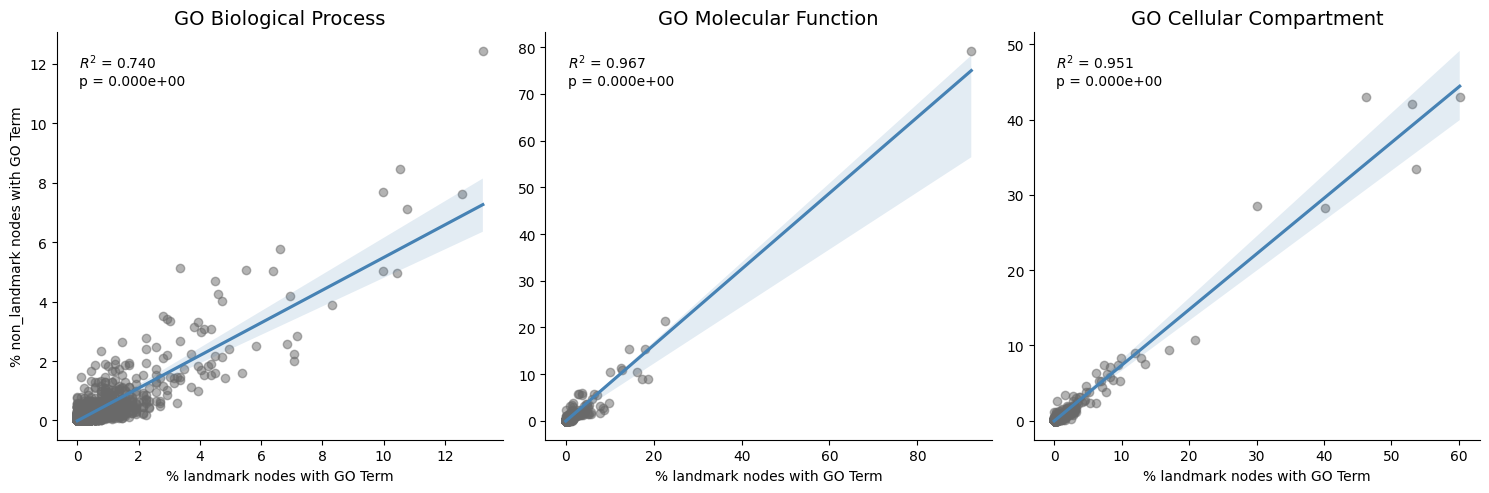

In [13]:
# Plot dat
plot = sns.lmplot(df_david, x = 'landmark', y = 'non_landmark', col = 'category',
                  sharex = False, sharey = False, aspect = 1, ci = 95,
                  scatter_kws = {'color' : 'dimgrey', 'alpha' : 0.5},
                  line_kws = {'color' : 'steelblue'})
plot.set_titles('{col_name}', size = 14)

for ax, (facet_value, subdf) in zip(plot.axes.flat, df_david.groupby('category')):
    
    res = stats.linregress(subdf['landmark'], subdf['non_landmark'])
    
    r2 = res.rvalue ** 2
    p = res.pvalue
    
    ax.text(
        0.05, 0.95,
        f"$R^2$ = {r2:.3f}\np = {p:.3e}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )

plot.set_xlabels('% landmark nodes with GO Term')
plot.set_ylabels('% non_landmark nodes with GO Term')